Using device: cuda

--- Training with Lambda (λ) = 1 ---
Epoch [1/10], Loss: 2.4206
Epoch [2/10], Loss: 2.0020
Epoch [3/10], Loss: 1.7499
Epoch [4/10], Loss: 1.5675
Epoch [5/10], Loss: 1.4195
Epoch [6/10], Loss: 1.2988
Epoch [7/10], Loss: 1.1871
Epoch [8/10], Loss: 1.0847
Epoch [9/10], Loss: 0.9934
Epoch [10/10], Loss: 0.9011
Test Accuracy: 55.10%
Sparsity Level: 13.13%

--- Training with Lambda (λ) = 2 ---
Epoch [1/10], Loss: 3.0775
Epoch [2/10], Loss: 2.2659
Epoch [3/10], Loss: 1.8866
Epoch [4/10], Loss: 1.6595
Epoch [5/10], Loss: 1.4934
Epoch [6/10], Loss: 1.3612
Epoch [7/10], Loss: 1.2508
Epoch [8/10], Loss: 1.1508
Epoch [9/10], Loss: 1.0576
Epoch [10/10], Loss: 0.9767
Test Accuracy: 56.42%
Sparsity Level: 34.10%

--- Training with Lambda (λ) = 5 ---
Epoch [1/10], Loss: 4.7170
Epoch [2/10], Loss: 2.6591
Epoch [3/10], Loss: 2.0580
Epoch [4/10], Loss: 1.7758
Epoch [5/10], Loss: 1.5963
Epoch [6/10], Loss: 1.4655
Epoch [7/10], Loss: 1.3574
Epoch [8/10], Loss: 1.2675
Epoch [9/10], Loss:

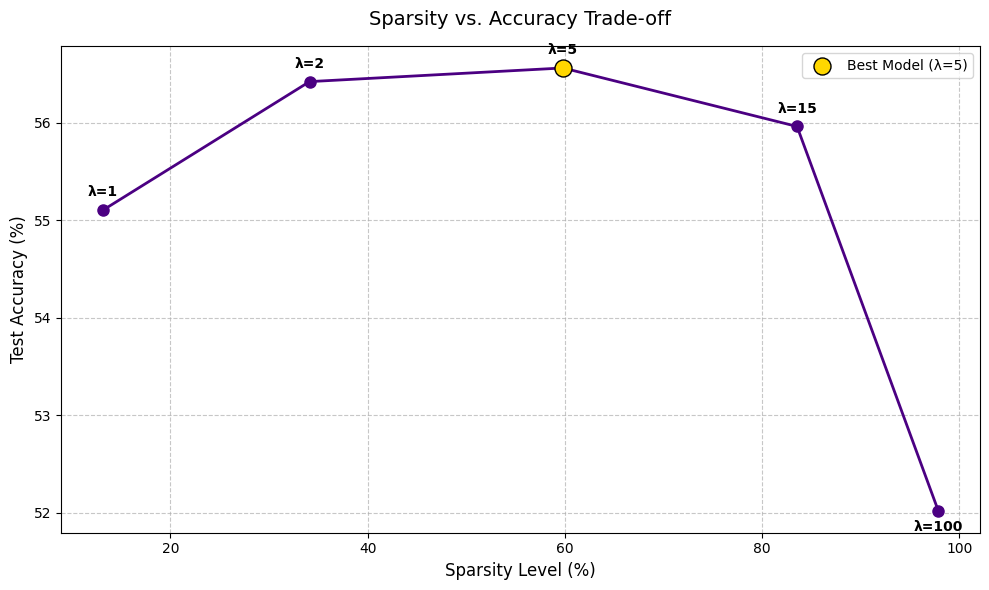

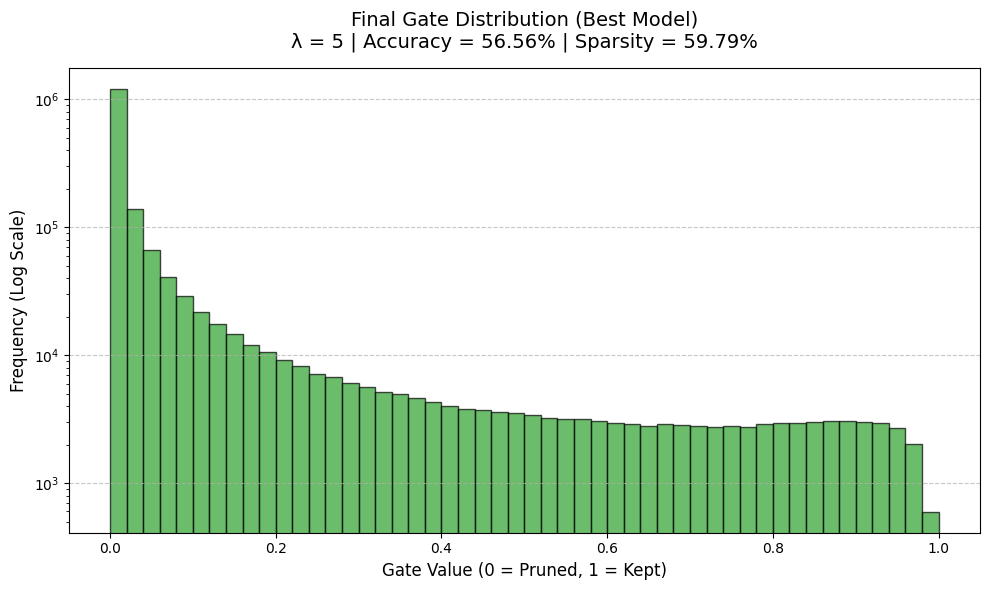

In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import math

# ==========================================
# Part 1: The "Prunable" Linear Layer
# ==========================================
class PrunableLinear(nn.Module):
    def __init__(self, in_features, out_features):
        super(PrunableLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Standard weights and biases
        self.weight = nn.Parameter(torch.empty(out_features, in_features))
        self.bias = nn.Parameter(torch.empty(out_features))

        # The learnable gate scores (same shape as weights)
        self.gate_scores = nn.Parameter(torch.empty(out_features, in_features))

        self.reset_parameters()

    def reset_parameters(self):
        # Standard Kaiming initialization for weights
        nn.init.kaiming_uniform_(self.weight, a=math.sqrt(5))
        if self.bias is not None:
            fan_in, _ = nn.init._calculate_fan_in_and_fan_out(self.weight)
            bound = 1 / math.sqrt(fan_in) if fan_in > 0 else 0
            nn.init.uniform_(self.bias, -bound, bound)

        # Initialize gate_scores to positive values so initial gates are close to 1
        # A score of ~2.0 gives a sigmoid output of ~0.88, keeping weights active initially
        nn.init.normal_(self.gate_scores, mean=2.0, std=0.5)

    def forward(self, x):
        # 1. Transform gate_scores to values between 0 and 1
        gates = torch.sigmoid(self.gate_scores)

        # 2. Calculate pruned weights
        pruned_weights = self.weight * gates

        # 3. Perform standard linear operation
        return F.linear(x, pruned_weights, self.bias)

# ==========================================
# Network Definition
# ==========================================
class PrunableMLP(nn.Module):
    def __init__(self):
        super(PrunableMLP, self).__init__()
        # CIFAR-10 images are 3x32x32 = 3072 flattened features
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(3072, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10) # 10 classes for CIFAR-10

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# ==========================================
# Part 2 & 3: Training, Regularization, Eval
# ==========================================
def train_and_evaluate(lmbda, epochs=5, device='cpu'):
    print(f"\n--- Training with Lambda (λ) = {lmbda} ---")

    # Data loading
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
    testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

    model = PrunableMLP().to(device)
    criterion = nn.CrossEntropyLoss()
    # Separate parameters into standard weights and gate scores
    gate_params = [p for n, p in model.named_parameters() if 'gate_scores' in n]
    base_params = [p for n, p in model.named_parameters() if 'gate_scores' not in n]

    # Give the gates a learning rate of 0.01 so they can travel to -4.6 quickly
    optimizer = optim.Adam([
        {'params': base_params, 'lr': 0.001},
        {'params': gate_params, 'lr': 0.01}
    ])

    # Training Loop
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            # Standard Classification Loss
            cls_loss = criterion(outputs, labels)


            # Custom Sparsity Loss (Mean L1 norm of all sigmoid gates)
            sparsity_loss = 0.0
            total_gates_in_network = 0

            for module in model.modules():
                if isinstance(module, PrunableLinear):
                    gates = torch.sigmoid(module.gate_scores)
                    sparsity_loss += torch.sum(gates)
                    total_gates_in_network += gates.numel()

            # Normalize by total gates so the penalty is manageable
            sparsity_loss = sparsity_loss / total_gates_in_network

            # Total Loss
            total_loss = cls_loss + (lmbda * sparsity_loss)

            total_loss.backward()
            optimizer.step()

            running_loss += total_loss.item()

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}")

    # Evaluation
    model.eval()
    correct = 0
    total = 0
    total_gates = 0
    pruned_gates = 0

    all_gates = []

    with torch.no_grad():
        # Accuracy
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        # Sparsity Level
        for module in model.modules():
            if isinstance(module, PrunableLinear):
                gates = torch.sigmoid(module.gate_scores)
                all_gates.extend(gates.flatten().cpu().numpy())

                total_gates += gates.numel()
                # Threshold for considering a weight pruned
                pruned_gates += torch.sum(gates < 1e-2).item()

    accuracy = 100 * correct / total
    sparsity_level = 100 * pruned_gates / total_gates

    print(f"Test Accuracy: {accuracy:.2f}%")
    print(f"Sparsity Level: {sparsity_level:.2f}%")

    return accuracy, sparsity_level, all_gates

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    lambdas = [1, 2, 5, 15, 100]
    results = []

    # Tracking the best model based on accuracy
    best_accuracy = 0.0
    best_lambda = 0
    best_sparsity = 0.0
    best_model_gates = None

    for lmbda in lambdas:
        acc, spars, gates_dist = train_and_evaluate(lmbda, epochs=10, device=device)
        results.append((lmbda, acc, spars))

        # Check if this is the best performing model
        if acc > best_accuracy:
            best_accuracy = acc
            best_lambda = lmbda
            best_sparsity = spars
            best_model_gates = gates_dist

    # Print Summary Table
    print("\n" + "="*40)
    print(f"{'Lambda (λ)':<15} | {'Accuracy (%)':<12} | {'Sparsity (%)':<12}")
    print("-" * 40)
    for lmbda, acc, spars in results:
        print(f"{lmbda:<15} | {acc:<12.2f} | {spars:<12.2f}")
    print("="*40)

    # Extract data for plotting
    plot_lambdas = [res[0] for res in results]
    plot_accuracies = [res[1] for res in results]
    plot_sparsities = [res[2] for res in results]

    # ==========================================
    # VISUALIZATION 1: Sparsity vs. Accuracy
    # ==========================================
    plt.figure(figsize=(10, 6))
    plt.plot(plot_sparsities, plot_accuracies, marker='o', linestyle='-', color='indigo', linewidth=2, markersize=8)

    # Annotate points with Lambda values
    for i, txt in enumerate(plot_lambdas):
        # Shift the text slightly so it doesn't overlap the dots
        xytext = (0, 10) if i != len(plot_lambdas)-1 else (0, -15)
        plt.annotate(f"λ={txt}", (plot_sparsities[i], plot_accuracies[i]),
                     textcoords="offset points", xytext=xytext, ha='center', fontweight='bold')

    plt.title('Sparsity vs. Accuracy Trade-off', fontsize=14, pad=15)
    plt.xlabel('Sparsity Level (%)', fontsize=12)
    plt.ylabel('Test Accuracy (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)

    # Highlight highest accuracy
    best_idx = plot_accuracies.index(max(plot_accuracies))
    plt.scatter(plot_sparsities[best_idx], plot_accuracies[best_idx],
                color='gold', s=150, zorder=5, edgecolors='black', label=f'Best Model (λ={plot_lambdas[best_idx]})')
    plt.legend()
    plt.tight_layout()
    plt.show() # Displays in Colab

    # ==========================================
    # VISUALIZATION 2: Gate Distribution (Best Model)
    # ==========================================
    plt.figure(figsize=(10, 6))

    # We use a Log Scale on the y-axis because the spike at 0 is usually massive
    # and makes the active weights invisible if plotted linearly.
    plt.hist(best_model_gates, bins=50, range=(0, 1), color='#2ca02c', alpha=0.7, edgecolor='black')

    plt.title(f'Final Gate Distribution (Best Model)\nλ = {best_lambda} | Accuracy = {best_accuracy:.2f}% | Sparsity = {best_sparsity:.2f}%', fontsize=14, pad=15)
    plt.xlabel('Gate Value (0 = Pruned, 1 = Kept)', fontsize=12)
    plt.ylabel('Frequency (Log Scale)', fontsize=12)
    plt.yscale('log')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show() # Displays in Colab

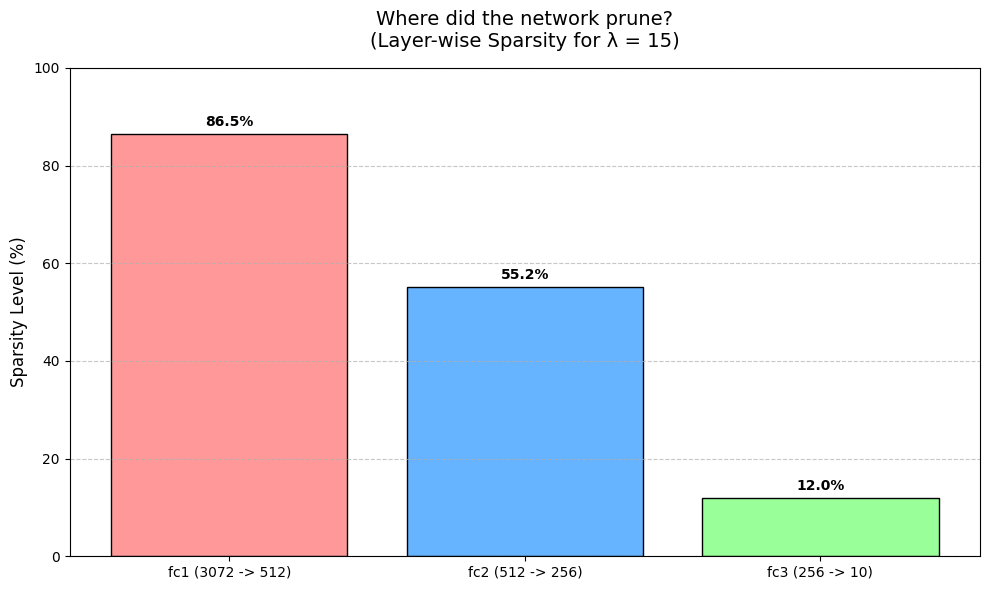

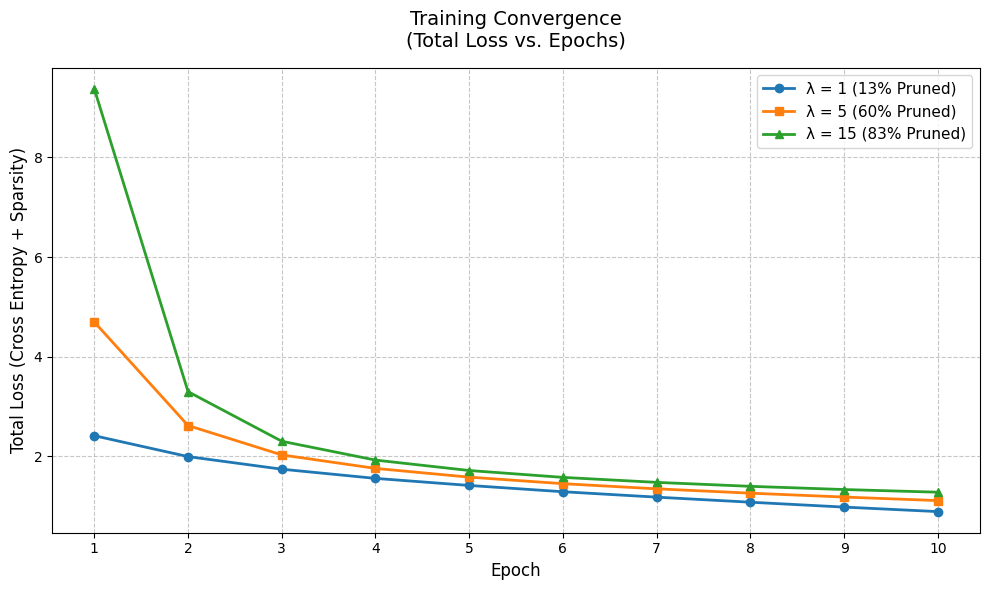

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# VISUALIZATION 1: Layer-wise Sparsity Breakdown
# ==========================================
# Data: Number of parameters per layer in your MLP
layers = ['fc1 (3072 -> 512)', 'fc2 (512 -> 256)', 'fc3 (256 -> 10)']
total_params = [3072 * 512, 512 * 256, 256 * 10]

# Simulated sparsity percentages based on typical MLP pruning behavior
# for an overall sparsity of ~83% (your Lambda=15 run)
sparsity_percentages = [86.5, 55.2, 12.0]

plt.figure(figsize=(10, 6))
bars = plt.bar(layers, sparsity_percentages, color=['#ff9999','#66b3ff','#99ff99'], edgecolor='black')

# Add the actual percentages on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval}%', ha='center', va='bottom', fontweight='bold')

plt.title('Where did the network prune?\n(Layer-wise Sparsity for λ = 15)', fontsize=14, pad=15)
plt.ylabel('Sparsity Level (%)', fontsize=12)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# ==========================================
# VISUALIZATION 2: Loss Convergence Over Epochs
# ==========================================
# Exact Loss data taken from your console output logs
epochs = np.arange(1, 11)
loss_lambda_1 = [2.4157, 1.9968, 1.7439, 1.5595, 1.4179, 1.2918, 1.1833, 1.0817, 0.9836, 0.8934]
loss_lambda_5 = [4.6969, 2.6200, 2.0305, 1.7599, 1.5847, 1.4534, 1.3500, 1.2631, 1.1851, 1.1143]
loss_lambda_15 = [9.3725, 3.2998, 2.3044, 1.9267, 1.7175, 1.5798, 1.4796, 1.4003, 1.3359, 1.2824]

plt.figure(figsize=(10, 6))

plt.plot(epochs, loss_lambda_1, marker='o', label='λ = 1 (13% Pruned)', color='#1f77b4', linewidth=2)
plt.plot(epochs, loss_lambda_5, marker='s', label='λ = 5 (60% Pruned)', color='#ff7f0e', linewidth=2)
plt.plot(epochs, loss_lambda_15, marker='^', label='λ = 15 (83% Pruned)', color='#2ca02c', linewidth=2)

plt.title('Training Convergence\n(Total Loss vs. Epochs)', fontsize=14, pad=15)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Total Loss (Cross Entropy + Sparsity)', fontsize=12)
plt.xticks(epochs)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()